In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parametry
N = 31
dx = 1.0
x0 = 4
d = 4
max_relax_iteration = 500

# Współrzędne siatki
x = np.arange(-N, N+1)
y = np.arange(-N, N+1)
X, Y = np.meshgrid(x, y)

# Gęstość ładunku rho(x,y)
rho = np.exp(-((X - x0)**2 + Y**2) / d**2) - np.exp(-((X + x0)**2 + Y**2) / d**2)

def compute_S(u):
    S = 0.0
    for i in range(1, 2*N):
        for j in range(1, 2*N):
            dudx = (u[i+1, j] + u[i-1, j] - 2*u[i, j]) / dx**2
            dudy = (u[i, j+1] + u[i, j-1] - 2*u[i, j]) / dx**2
            S += -(0.5 * u[i, j] * (dudx + dudy) + rho[i, j] * u[i, j] )* dx**2
            
    return S

def compute_rho_prime(u):
    for i in range(1, 2*N):
        for j in range(1, 2*N):
            rho_prime[i, j] = -(u[i+1, j] + u[i-1, j] + u[i, j+1] + u[i, j-1] - 4*u[i, j]) / dx**2
            
    return rho_prime

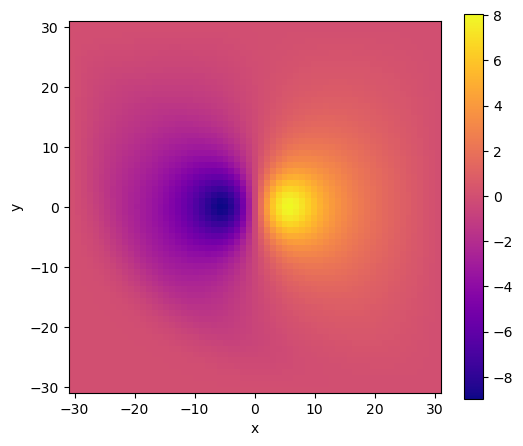

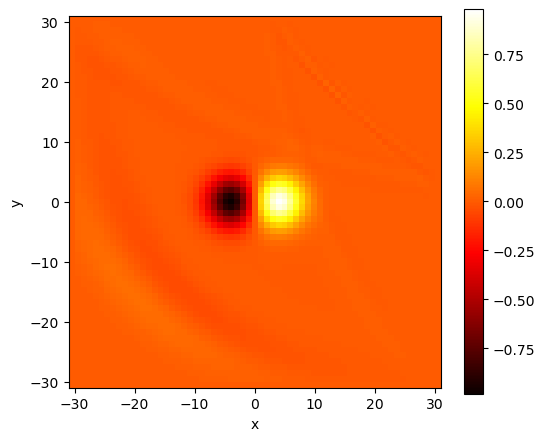

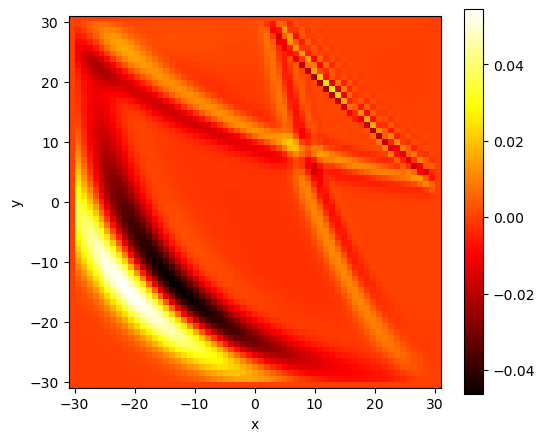

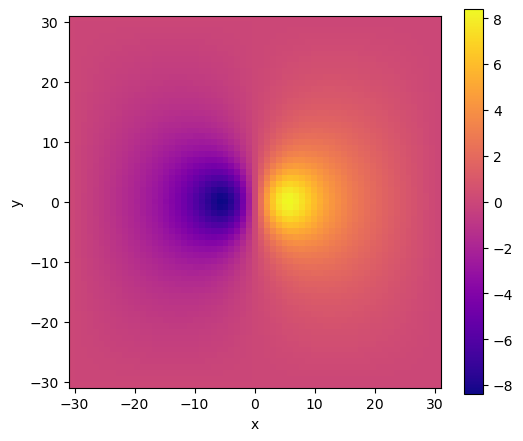

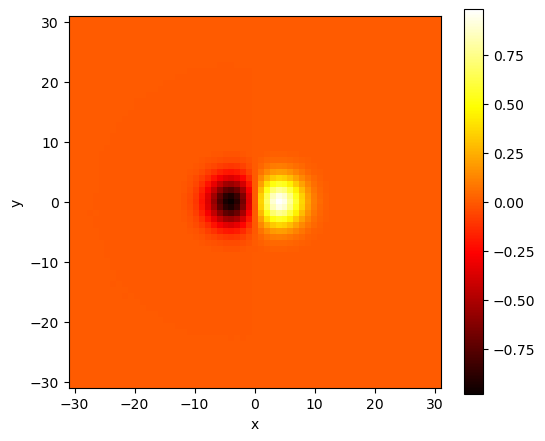

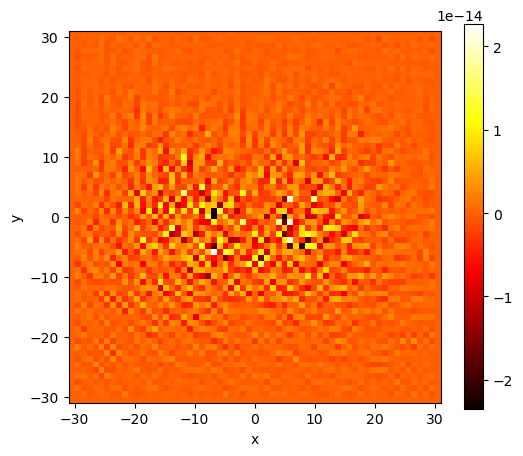

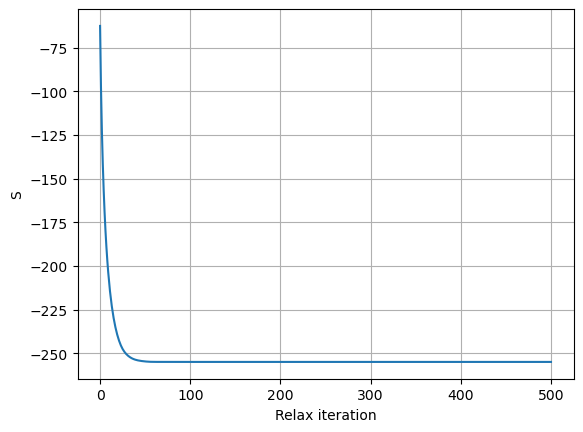

-255.01760343049986


In [28]:
u = np.zeros_like(rho)
rho_prime = np.zeros_like(rho)
S_tab = []
history = [] # wynik u po każdej iteracji (do animacji)

def relax(u, w=1, delta=0):
    u_new = (1-w)*u[i,j] + w*(u[i+1, j] + u[i-1, j] + u[i, j+1] + u[i, j-1] + rho[i, j] * dx**2) / 4
    return u_new + delta


# Pętla relaksacyjna
for relax_iteration in range(0, max_relax_iteration+1):

    for i in range(1, 2*N):
        for j in range(1, 2*N):
            u[i, j] = relax(u, w=1.9)
    
    S_tab.append(compute_S(u))
    rho_primeh = compute_rho_prime(u)
    delta_rhoh = rho_primeh - rho
    history.append(delta_rhoh) 

    if relax_iteration in [30, 500]:  # wykresy po 100(30) i 500 iteracjach
        
        # u(x, y)
        plt.figure(figsize=(6, 5))
        plt.imshow(u, extent=(-N, N, -N, N), cmap='plasma', origin='lower')
        plt.colorbar()
        plt.xlabel('x')
        plt.ylabel('y')
        plt.show()
        
        # rho prim
        plt.figure(figsize=(6, 5))
        plt.imshow(rho_prime, extent=(-N, N, -N, N), cmap='hot', origin='lower')
        plt.colorbar()
        plt.xlabel('x')
        plt.ylabel('y')
        plt.show()
        
        # delta_rho(x, y)
        rho_prime = compute_rho_prime(u)
        delta_rho = rho_prime - rho

        plt.figure(figsize=(6, 5))
        plt.imshow(delta_rho, extent=(-N, N, -N, N), cmap='hot', origin='lower')
        plt.colorbar()
        plt.xlabel('x')
        plt.ylabel('y')
        plt.show()

plt.plot(S_tab)
plt.xlabel('Relax iteration')
plt.ylabel('S')
plt.grid(True)
plt.show()


print(S_tab[-1])

In [3]:
w_values = [0.8, 1.0, 1.5, 1.9]
S_all = {}

for w in w_values:
    u = np.zeros_like(rho)
    S_tab = []

    for relax_iteration in range(1, max_relax_iteration + 1):
        for i in range(1, 2*N):
            for j in range(1, 2*N):
                u[i, j] = relax(u, w=w)
        S_tab.append(compute_S(u))

    S_all[w] = S_tab

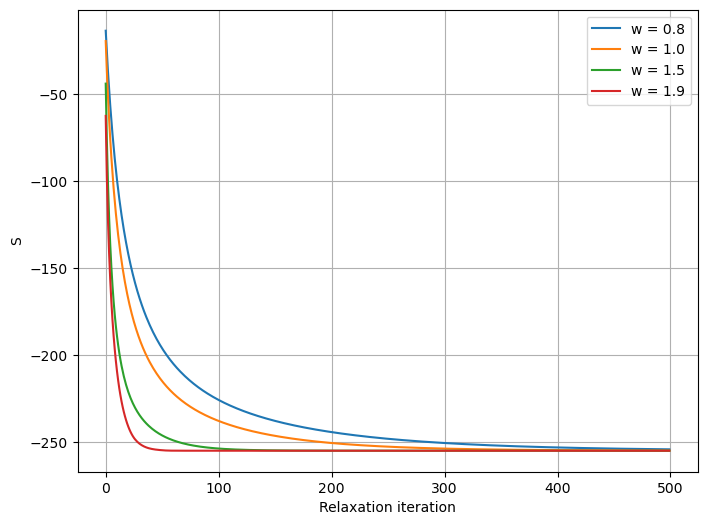

In [4]:
# Wykres porównawczy
plt.figure(figsize=(8, 6))
for w, S_tab in S_all.items():
    plt.plot(S_tab, label=f"w = {w}")

plt.xlabel("Relaxation iteration")
plt.ylabel("S")
plt.legend()
plt.grid(True)
plt.show()

Animacja

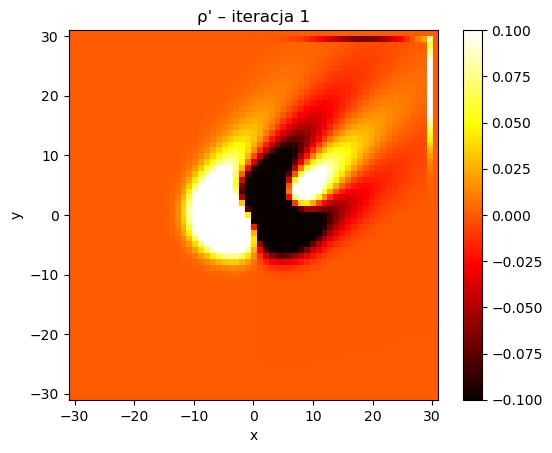

In [27]:

from matplotlib.animation import FuncAnimation

all_vals = np.array(history)
vmin = np.min(all_vals)
vmax = np.max(all_vals)


fig, ax = plt.subplots()
cax = ax.imshow(history[0], extent=(-N, N, -N, N), origin='lower',
                animated=True, cmap='hot', vmin=-0.1, vmax=0.1)
fig.colorbar(cax)
ax.set_title('Ewolucja u(x,y) podczas relaksacji')
ax.set_xlabel('x')
ax.set_ylabel('y')

def update(frame):
    cax.set_array(history[frame])
    ax.set_title(f'ρ\' – iteracja {frame+1}')
    return [cax]

anim = FuncAnimation(fig, update, frames=len(history), interval=100, blit=True)

plt.show()
anim.save('nadrelaksacja.gif', writer='pillow')


# ZADANIE 3

In [6]:
u = np.zeros_like(rho)
rho_prime = np.zeros_like(rho)
S_tab = []
deltas = [0, 0.5, 1]
S_deltas = []

def compute_S(u):
    S = 0.0
    for i in range(1, 2*N):
        for j in range(1, 2*N):
            dudx = (u[i+1, j] + u[i-1, j] - 2*u[i, j]) / dx**2
            dudy = (u[i, j+1] + u[i, j-1] - 2*u[i, j]) / dx**2
            S += -(0.5 * u[i, j] * (dudx + dudy) + rho[i, j] * u[i, j] )* dx**2
            
    return S

def compute_S_local(u, i0, j0, delta=0):
    S_loc = 0.0
    u_new = u.copy()
    u_new[i, j] += delta
    for i in range(i0 - 1, i0 + 2):
        for j in range(j0 - 1, j0 + 2):
            dudx = (u_new[i+1, j] + u_new[i-1, j] - 2*u_new[i, j]) / dx**2
            dudy = (u_new[i, j+1] + u_new[i, j-1] - 2*u_new[i, j]) / dx**2
            S_loc += -(0.5 * u_new[i, j] * (dudx + dudy) + rho[i, j] * u_new[i, j] )* dx**2
            
    return S_loc


def relax(u, w=1, delta=0):
    u_new = (1-w)*u[i, j] + w*(u[i+1, j] + u[i-1, j] + u[i, j+1] + u[i, j-1] + rho[i, j] * dx**2) / 4
    return u_new + delta



 

In [8]:
def compute_S_local(u, i0, j0, delta=0):
    S_loc = 0.0
    u_new = u.copy()
    u_new[i0, j0] += delta
    for i in range(i0 - 1, i0 + 2):
        for j in range(j0 - 1, j0 + 2):
            dudx = (u_new[i+1, j] + u_new[i-1, j] - 2*u_new[i, j]) / dx**2
            dudy = (u_new[i, j+1] + u_new[i, j-1] - 2*u_new[i, j]) / dx**2
            S_loc += -(0.5 * u_new[i, j] * (dudx + dudy) + rho[i, j] * u_new[i, j] )* dx**2
            
    return S_loc


u = np.zeros_like(rho)
S_tab = []
S_iteration = []
deltas_tab = []
for relax_iteration in range(1, max_relax_iteration + 1):
    
    S0 = compute_S(u)
    
    for i in range(1, 2*N - 1):
        for j in range(1, 2*N - 1):         
            deltas = [0.0, 0.5, 1.0]
            
            
            S_loc = compute_S_local(u, i, j, 0.0)
            
            S_vals = []
            for delta in deltas:
                S_mod = S0 - S_loc + compute_S_local(u, i, j, delta)
                S_vals.append(S_mod)
            
            S_0, S_1, S_2 = S_vals
            numerator = 3*S_0 - 4*S_1 + S_2
            denominator = S_0 - 2*S_1 + S_2
            
            if denominator != 0:
                delta_4 = 0.25 * (numerator / denominator)
            else:
                delta_4 = 0.0

            deltas.append(delta_4)
            S_3 = S0 - S_loc + compute_S_local(u, i, j, delta_4)
            S_vals.append(S_3)

            imin = np.argmin(S_vals)
            delta_best = deltas[imin]
            u[i, j] += delta_best
            S0 = S_vals[imin]

   
    S_tab.append(S0)
    S_iteration.append(S_tab[-1])

-254.54468552563512


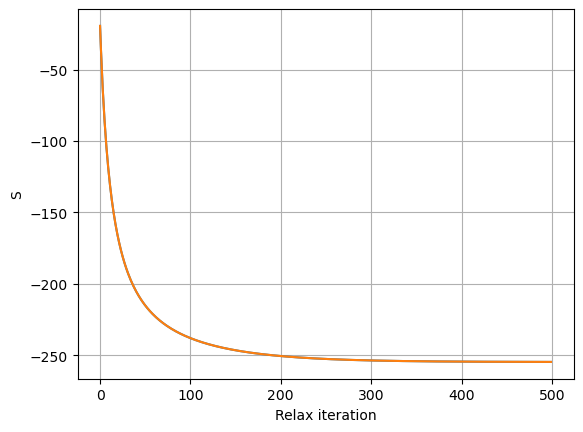

In [9]:
print(S_iteration[-1])
plt.plot(S_iteration, label="Bezpośrednia minimalizacja")
plt.plot(S_tab, label="Metoda relaksacji w=1.0")
plt.xlabel('Relax iteration')
plt.ylabel('S')
plt.grid(True)
plt.show()

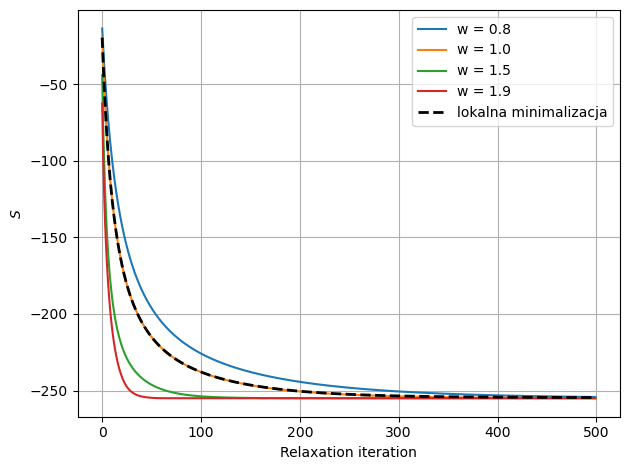

In [10]:
plt.figure()

for w in w_values:
    plt.plot(S_all[w], label=f"w = {w}")
plt.plot(S_iteration, label="lokalna minimalizacja", linewidth=2, linestyle='--', color='black')
plt.xlabel("Relaxation iteration")
plt.ylabel("$S$")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [2]:
def compute_S_local(u, i0, j0, delta=0):
    S_loc = 0.0
    u_new = u.copy()
    u_new[i0, j0] += delta
    for i in range(i0 - 1, i0 + 2):
        for j in range(j0 - 1, j0 + 2):
            dudx = (u_new[i+1, j] + u_new[i-1, j] - 2*u_new[i, j]) / dx**2
            dudy = (u_new[i, j+1] + u_new[i, j-1] - 2*u_new[i, j]) / dx**2
            S_loc += -(0.5 * u_new[i, j] * (dudx + dudy) + rho[i, j] * u_new[i, j] )* dx**2
            
    return S_loc

In [ ]:
#beta = 0.4
d = 0.001

beta_values = [0.1, 0.2, 0.3, 0.4, 0.45]
S_betas = {}

for beta in beta_values:
    u = np.zeros_like(rho)
    S_values = []
    for relax_iteration in range(1, max_relax_iteration + 1):
        for i in range(1, 2*N-1):
            for j in range(1, 2*N-1):
                S_plus = compute_S_local(u, i, j, +d)
                S_minus = compute_S_local(u, i, j, -d)
                grad_S = (S_plus - S_minus) / (2 * d)
                u[i, j] -= beta * grad_S

        S_values.append(compute_S(u))
        #print(f"Iteracja {relax_iteration+1}, S = {S_now:.5f}")
    S_betas[beta] = S_values

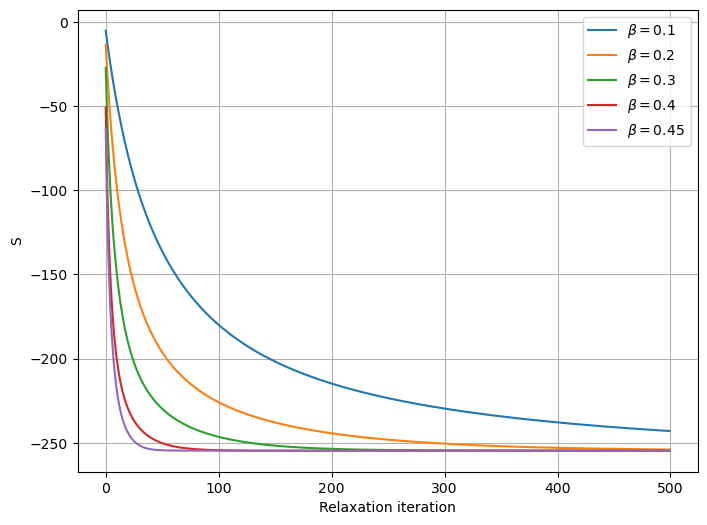

In [12]:
# Wykres porównawczy
plt.figure(figsize=(8, 6))
for beta, S_values in S_betas.items():
    plt.plot(S_values, label=fr"$\beta = {beta}$")


plt.xlabel("Relaxation iteration")
plt.ylabel("S")
plt.legend()
plt.grid(True)
plt.show()

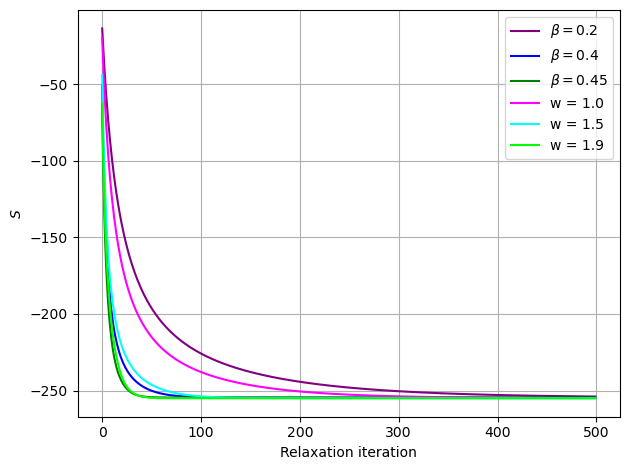

In [13]:

selected_betas = [0.2, 0.4, 0.45]
selected_w = [1.0,1.5, 1.9]

colors_beta = ['purple','blue','green', 'red']
colors_w = ['fuchsia', 'cyan', 'lime','orange']

plt.figure()

for i, (beta, S_values) in enumerate(S_betas.items()):
    if beta in selected_betas:
        color = colors_beta[selected_betas.index(beta)]
        plt.plot(S_values, label=fr"$\beta = {beta}$", color=color)

for i, w in enumerate(w_values):
    if w in selected_w:
        color = colors_w[selected_w.index(w)]
        plt.plot(S_all[w], label=f"w = {w}", color=color)

plt.xlabel("Relaxation iteration")
plt.ylabel("$S$")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [30]:
r = 0.07
u = np.zeros_like(rho)
S_values = []


S_current = compute_S(u)
for relax_iteration in range(1, max_relax_iteration + 1):
    
    for i in range(1, 2*N-1):
        for j in range(1, 2*N-1):
            delta = np.random.uniform(-r, r)
            #print(delta)
            Sloc = compute_S_local(u, i, j)
            S_trial = compute_S_local(u, i, j, delta)
            #print(f"Trial: {S_trial}")
            #print(f"Current: {S_current}")

            if S_trial < Sloc:
                #print(S_current)
                u[i, j] += delta
                S_current = S_current - Sloc + S_trial

    S_values.append(compute_S(u))
    #print(f"Iteracja {relax_iteration+1}, S = {S_current:.5f}")

-225.98917248315436


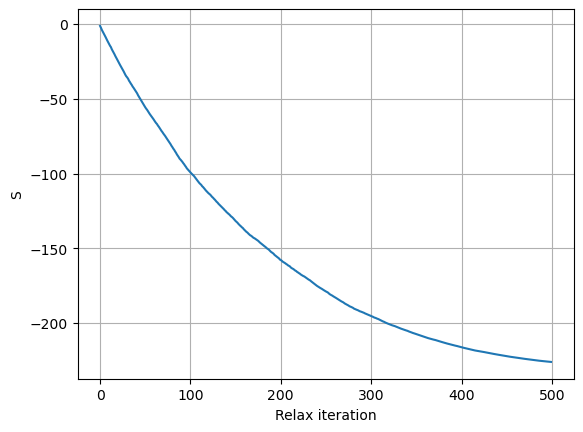

In [32]:
print(S_values[-1])
plt.plot(S_values)
plt.xlabel('Relax iteration')
plt.ylabel('S')
plt.grid(True)
plt.show()

In [13]:
r_arr = np.linspace(0.02, 0.11, 10)
r = 0.08


S_valuess = []
for r in r_arr:
    u = np.zeros_like(rho)
    S_current = compute_S(u)
    for relax_iteration in range(1, max_relax_iteration + 1):
        for i in range(1, 2*N-1):
            for j in range(1, 2*N-1):
                delta = np.random.uniform(-r, r)
                Sloc = compute_S_local(u, i, j)
                S_trial = compute_S_local(u, i, j, delta)
                if S_trial < Sloc:
                    u[i, j] += delta
                    S_current = S_current - Sloc + S_trial

    S_values.append(compute_S(u))
    print(S_values)

[-141.07839482527012]
[-141.07839482527012, -181.21265383407714]
[-141.07839482527012, -181.21265383407714, -204.36191631871125]
[-141.07839482527012, -181.21265383407714, -204.36191631871125, -217.8699948524534]
[-141.07839482527012, -181.21265383407714, -204.36191631871125, -217.8699948524534, -224.24500980737815]
[-141.07839482527012, -181.21265383407714, -204.36191631871125, -217.8699948524534, -224.24500980737815, -226.0779990897343]
[-141.07839482527012, -181.21265383407714, -204.36191631871125, -217.8699948524534, -224.24500980737815, -226.0779990897343, -226.3690032114131]
[-141.07839482527012, -181.21265383407714, -204.36191631871125, -217.8699948524534, -224.24500980737815, -226.0779990897343, -226.3690032114131, -226.17704339673656]
[-141.07839482527012, -181.21265383407714, -204.36191631871125, -217.8699948524534, -224.24500980737815, -226.0779990897343, -226.3690032114131, -226.17704339673656, -225.32526074833754]
[-141.07839482527012, -181.21265383407714, -204.36191631871

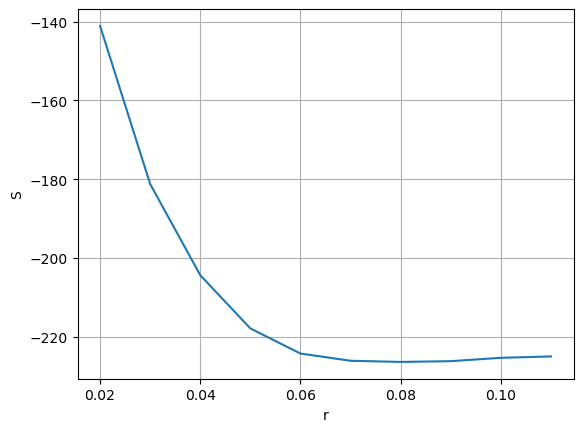

In [15]:
plt.plot(r_arr, S_values)
plt.xlabel('r')
plt.ylabel('S')
plt.grid(True)
plt.show()